# Factuality distribution — by work

All 391 clean non-historian works (selected English translation, excluding Unknown & Pseudo-Plutarch, valid author impact date) classified on a 4-level factuality scale based on the type of evidence they provide about contemporary social rules.

| Score | Type of evidence | Example |
|---|---|---|
| 1 | Tragedy, myth, epic, or speculative framing. The rule reflects the author's era only obliquely. | Sophocles' *Antigone* on burial rights |
| 2 | Contemporary prose, poems or treatises implying the rule exists in the author's own society without quoting it. | Aristotle describing the selection of archons in the *Athenaion Politeia* |
| 3 | Court speech or oration invoking a specific extant law or procedure. | Demosthenes speeches |
| 4 | Original legal text, statute, or constitutional clause quoted verbatim. | Draco's Homicide Law |

Raw 1–5 scores in `works_factuality_v18.tsv` are remapped: `1 → 1`, `2 → 2`, `3 → 2`, `4 → 3`, `5 → 4` (old "indirect inference" merged into "contemporary documentation").

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

WORKS_TSV = Path('../data/works_factuality_v18.tsv')
FACT_REMAP = {1: 1, 2: 2, 3: 2, 4: 3, 5: 4}

df = pd.read_csv(WORKS_TSV, sep='\t')
df['factuality'] = df['factuality'].map(FACT_REMAP)
print(f'Total works: {len(df):,}')

Total works: 391


In [2]:
LABELS = {
    1: '1 \u2014 Tragedy / myth / speculative',
    2: '2 \u2014 Contemporary prose, poems or treatises',
    3: '3 \u2014 Court speech / oration',
    4: '4 \u2014 Original legal text',
}

counts = df['factuality'].value_counts().reindex(range(1, 5), fill_value=0)
total = counts.sum()
print(f'Classified works: {total:,}')
counts

Classified works: 391


factuality
1     73
2    166
3    152
4      0
Name: count, dtype: int64

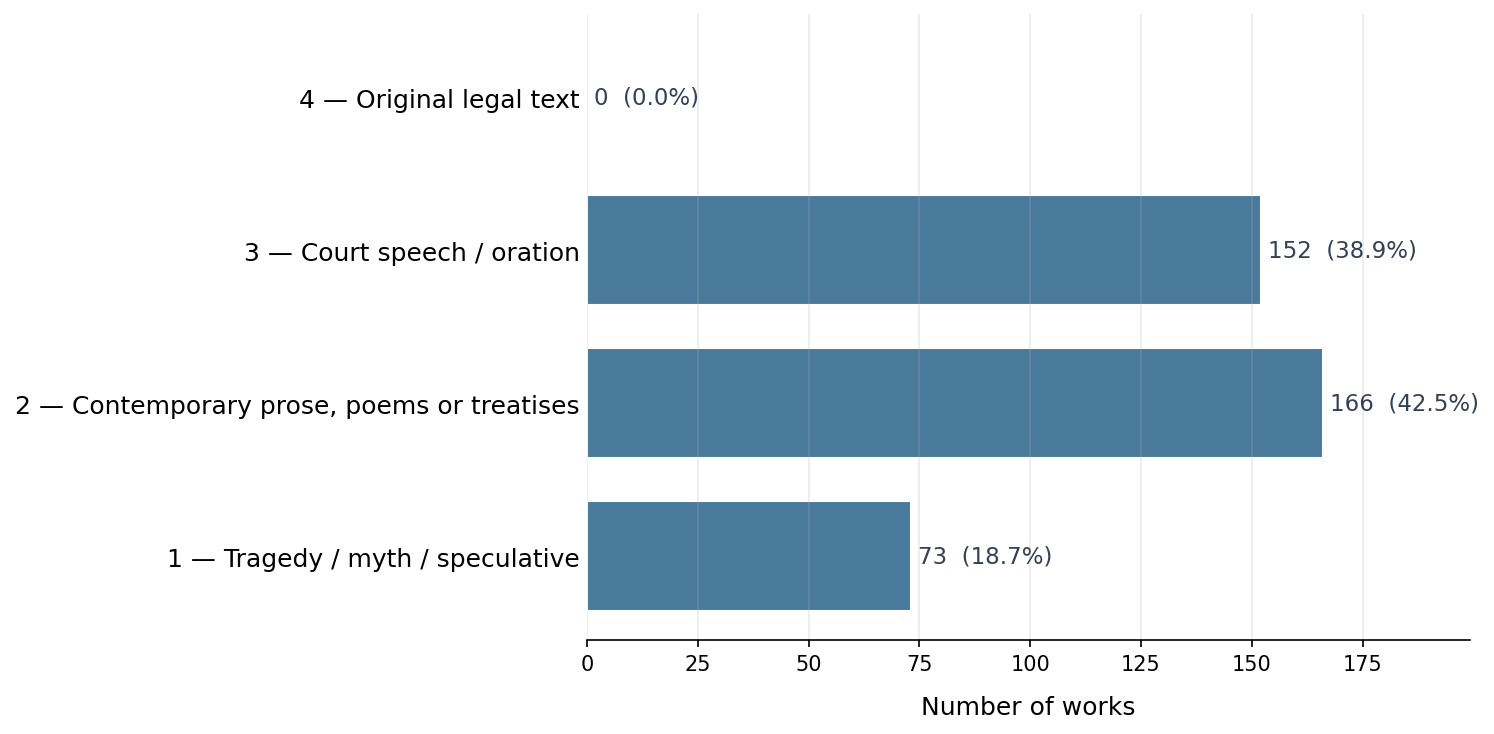

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

y = range(4, 0, -1)
labels = [LABELS[i] for i in range(4, 0, -1)]
values = [int(counts.get(i, 0)) for i in range(4, 0, -1)]

ax.barh(y, values, color='#4a7a9b', edgecolor='white', height=0.72)

for yi, v in zip(y, values):
    pct = v / total * 100 if total else 0
    ax.text(v + max(values) * 0.01, yi,
            f'{v:,}  ({pct:.1f}%)',
            va='center', fontsize=11, color='#334155')

ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Number of works', fontsize=12, labelpad=10)
ax.set_xlim(0, max(values) * 1.2)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()